# High Demand Class & Time Analysis
## Fitness Class Booking Demand Intelligence

In [1]:
# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# =========================================================
# LOAD CLEANED DATASET
# =========================================================

df = pd.read_csv('/content/cleaned_preprocessed_dataset_Tejaswini Yeluduti.csv')

print("Dataset Loaded Successfully")

display(df.head())

Dataset Loaded Successfully


,activity_site_id,activity_description,booking_end_datetime,booking_start_time,max_bookees,number_booked,price_inr,year,month,day,day_name
0,HXP,20-20-20 2.45pm-3.45pm,2018-04-08,14:45:00,-0.475775,12,-1.709436,2018,4,8,Sunday
1,HXP,20-20-20 2.45pm-3.45pm,2018-04-15,14:45:00,-0.475775,15,-1.709436,2018,4,15,Sunday
2,HXP,20-20-20 2.45pm-3.45pm,2018-04-22,14:45:00,-0.475775,14,-1.709436,2018,4,22,Sunday
3,HXP,20-20-20 2.45pm-3.45pm,2018-04-29,14:45:00,-0.475775,9,-1.709436,2018,4,29,Sunday
4,HXP,20-20-20 2.45pm-3.45pm,2018-05-06,14:45:00,-0.475775,7,-1.709436,2018,5,6,Sunday


In [3]:
# =========================================================
# DATETIME CONVERSION & FEATURE ENGINEERING
# =========================================================

df['booking_end_datetime'] = pd.to_datetime(
    df['booking_end_datetime']
)

df['year'] = df['booking_end_datetime'].dt.year
df['month'] = df['booking_end_datetime'].dt.month
df['day'] = df['booking_end_datetime'].dt.day
df['day_name'] = df['booking_end_datetime'].dt.day_name()

print("Date Features Created Successfully")

Date Features Created Successfully


In [4]:
# =========================================================
# HIGH DEMAND CLASSES
# =========================================================

high_demand_classes = (
    df.groupby('activity_description')['number_booked']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(high_demand_classes)

,number_booked
activity_description,
Body Combat 7.00-8.00pm,1031
Aquafit 7.00-8.00pm,915
Pilates 1.45-2.45pm,730
Line Dance 10.45-11.45am,673
Body Con 10.30-11.30am,611
Pilates 9.30-10.30am,605
20-20-20 9.30-10.30am,592
Yoga 10.30-11.30am,584
Body Conditioning 10-11am,575


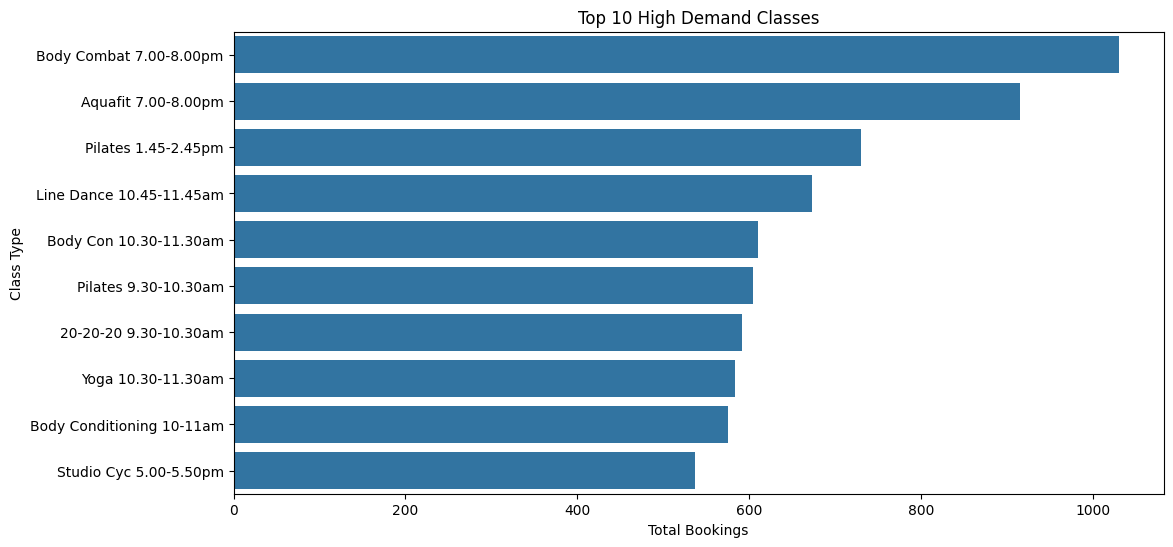

In [5]:
# =========================================================
# VISUALIZE HIGH DEMAND CLASSES
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x=high_demand_classes.values,
    y=high_demand_classes.index
)

plt.title('Top 10 High Demand Classes')

plt.xlabel('Total Bookings')
plt.ylabel('Class Type')

plt.show()

In [6]:
# =========================================================
# PEAK BOOKING DAYS
# =========================================================

peak_days = (
    df.groupby('day_name')['number_booked']
    .sum()
    .sort_values(ascending=False)
)

display(peak_days)

,number_booked
day_name,
Tuesday,12097
Wednesday,10737
Monday,9253
Thursday,8777
Friday,7294
Saturday,4766
Sunday,3281


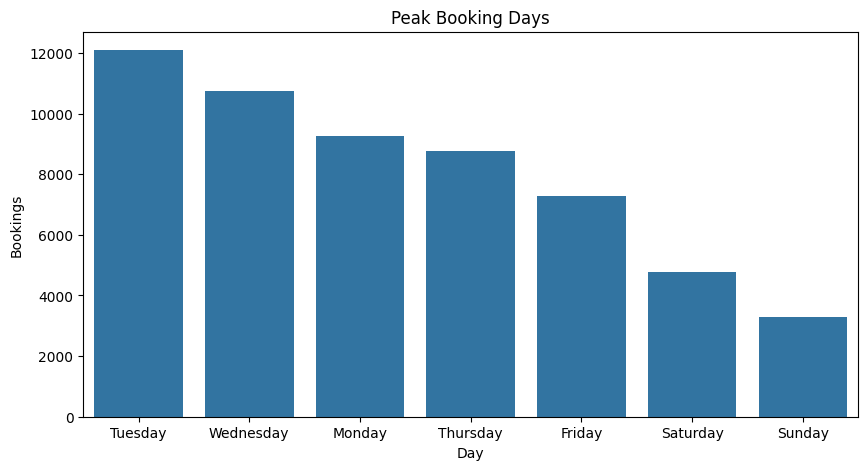

In [7]:
# =========================================================
# VISUALIZE PEAK BOOKING DAYS
# =========================================================

plt.figure(figsize=(10,5))

sns.barplot(
    x=peak_days.index,
    y=peak_days.values
)

plt.title('Peak Booking Days')

plt.xlabel('Day')
plt.ylabel('Bookings')

plt.show()

In [8]:
# =========================================================
# PEAK MONTH ANALYSIS
# =========================================================

monthly_demand = (
    df.groupby('month')['number_booked']
    .sum()
)

display(monthly_demand)

,number_booked
month,
4,19592
5,18855
6,17758
